In [1]:
import os
import math
import torch
import xml.etree.ElementTree as ET
from PIL import Image
from torch.utils.data import Dataset
from torchvision import transforms

In [2]:
device = "cuda"

In [3]:
class CustomVOCDataset(Dataset):
    def __init__(self, img_dir, ann_dir):
        self.img_dir = img_dir
        self.ann_dir = ann_dir
        self.xml_files = sorted([
            f for f in os.listdir(ann_dir) if f.endswith(".xml")
        ])
        self.class_map = {
            "banana": 0,
            "apple": 1
        }
        self.transform = transforms.Compose([
            transforms.Resize((64, 64)),
            transforms.ToTensor()
        ])

    def __len__(self):
        return len(self.xml_files)

    def parse_xml(self, xml_path, W, H):
        tree = ET.parse(xml_path)
        root = tree.getroot()    
        obj = root.find("object")
        label_name = obj.find("name").text.strip()
        label = self.class_map[label_name]    
        bbox = obj.find("bndbox")
        xmin = int(bbox.find("xmin").text)
        ymin = int(bbox.find("ymin").text)
        xmax = int(bbox.find("xmax").text)
        ymax = int(bbox.find("ymax").text)    
        cx = (xmin + xmax) / 2 / W
        cy = (ymin + ymax) / 2 / H
        bw = (xmax - xmin) / W
        bh = (ymax - ymin) / H    
        return (torch.tensor([cx, cy, bw, bh], dtype=torch.float32), torch.tensor(label, dtype=torch.long))

    def __getitem__(self, idx):
        xml_name = self.xml_files[idx]
        xml_path = os.path.join(self.ann_dir, xml_name)    
        base_name = os.path.splitext(xml_name)[0]
        img_path = os.path.join(self.img_dir, base_name + ".jpg")    
        image = Image.open(img_path).convert("RGB")
        orig_w, orig_h = image.size    
        image = self.transform(image)    
        box, label = self.parse_xml(xml_path, orig_w, orig_h)
        return image, box, label

In [4]:
from torch.utils.data import DataLoader

train_dataset = CustomVOCDataset(img_dir="datasets/object_detection/images",ann_dir="datasets/object_detection/train_labels")
test_dataset = CustomVOCDataset(img_dir="datasets/object_detection/images",ann_dir="datasets/object_detection/test_labels")

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
test_loader = DataLoader(test_dataset,batch_size=256,shuffle=False)

In [5]:
import torch.nn as nn
import torch.nn.functional as F

In [6]:
class CustomDetector(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.flatten = nn.Flatten()
        self.fc = nn.Sequential(
            nn.Linear(4096, 512),
            nn.ReLU()
        )
        # Bounding box head
        self.box_head = nn.Linear(512, 4)
        self.class_head = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = self.flatten(x)
        x = self.fc(x)
        boxes = self.box_head(x)
        class_logits = self.class_head(x)
        return boxes, class_logits

In [7]:
bbox_loss_fn = nn.SmoothL1Loss()
class_loss_fn = nn.CrossEntropyLoss()

In [8]:
model = CustomDetector(num_classes=2).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [9]:
model.to(device)

CustomDetector(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc): Sequential(
    (0): Linear(in_features=4096, out_features=512, bias=True)
    (1): ReLU()
  )
  (box_head): Linear(in_features=512, out_features=4, bias=True)
  (class_head): Linear(in_features=512, out_features=2, bias=True)
)

In [10]:
from tqdm import tqdm
num_epochs = 200

for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    for images, boxes, labels in train_loader:
        images = images.to(device)
        boxes = boxes.to(device)
        labels = labels.to(device)
        pred_boxes, class_logits = model(images)
        bbox_loss = bbox_loss_fn(pred_boxes, boxes)
        cls_loss = class_loss_fn(class_logits, labels)
        loss = bbox_loss + cls_loss
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f"Epoch [{epoch+1}/{num_epochs}] Loss: {total_loss:.4f}")

Epoch [1/200] Loss: 0.8664
Epoch [2/200] Loss: 0.8329
Epoch [3/200] Loss: 0.8044
Epoch [4/200] Loss: 0.7800
Epoch [5/200] Loss: 0.7583
Epoch [6/200] Loss: 0.7393
Epoch [7/200] Loss: 0.7228
Epoch [8/200] Loss: 0.7095
Epoch [9/200] Loss: 0.6999
Epoch [10/200] Loss: 0.6941
Epoch [11/200] Loss: 0.6918
Epoch [12/200] Loss: 0.6916
Epoch [13/200] Loss: 0.6919
Epoch [14/200] Loss: 0.6911
Epoch [15/200] Loss: 0.6882
Epoch [16/200] Loss: 0.6834
Epoch [17/200] Loss: 0.6771
Epoch [18/200] Loss: 0.6702
Epoch [19/200] Loss: 0.6632
Epoch [20/200] Loss: 0.6564
Epoch [21/200] Loss: 0.6500
Epoch [22/200] Loss: 0.6439
Epoch [23/200] Loss: 0.6378
Epoch [24/200] Loss: 0.6315
Epoch [25/200] Loss: 0.6250
Epoch [26/200] Loss: 0.6179
Epoch [27/200] Loss: 0.6103
Epoch [28/200] Loss: 0.6020
Epoch [29/200] Loss: 0.5932
Epoch [30/200] Loss: 0.5836
Epoch [31/200] Loss: 0.5735
Epoch [32/200] Loss: 0.5628
Epoch [33/200] Loss: 0.5516
Epoch [34/200] Loss: 0.5399
Epoch [35/200] Loss: 0.5278
Epoch [36/200] Loss: 0.5153
E

In [11]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

Original image size: (225, 225)


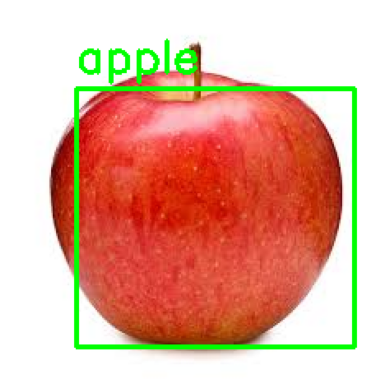

In [12]:
model.eval()

img_path = "test/apple.jpg"

img = Image.open(img_path).convert("RGB")
orig_w, orig_h = img.size
print("Original image size:", img.size)

inference_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

img_tensor = inference_transform(img).unsqueeze(0).to(device)

with torch.no_grad():
    pred_box, pred_cls = model(img_tensor)

pred_box = pred_box[0].cpu().numpy()   # [cx, cy, bw, bh]
pred_cls = torch.argmax(pred_cls, dim=1).item()

cx, cy, bw, bh = pred_box

x1 = int((cx - bw / 2) * orig_w)
y1 = int((cy - bh / 2) * orig_h)
x2 = int((cx + bw / 2) * orig_w)
y2 = int((cy + bh / 2) * orig_h)

x1 = max(0, min(x1, orig_w))
y1 = max(0, min(y1, orig_h))
x2 = max(0, min(x2, orig_w))
y2 = max(0, min(y2, orig_h))

idx_to_class = {0: "banana", 1: "apple"}
class_name = idx_to_class[pred_cls]

img_cv = cv2.imread(img_path)
cv2.rectangle(img_cv, (x1, y1), (x2, y2), (0, 255, 0), 2)
cv2.putText(
    img_cv,
    class_name,
    (x1, max(0, y1 - 10)),
    cv2.FONT_HERSHEY_SIMPLEX,
    0.9,
    (0, 255, 0),
    2
)

plt.imshow(cv2.cvtColor(img_cv, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

Original image size: (540, 360)


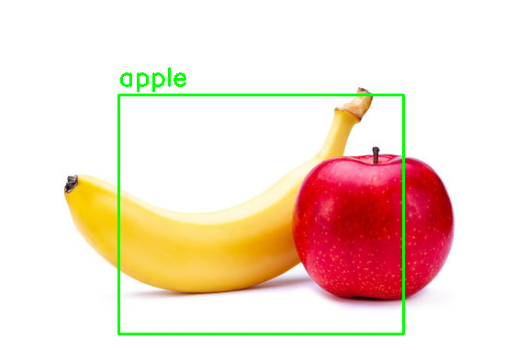

In [13]:
model.eval()

img_path = "test/apples.jpg"

img = Image.open(img_path).convert("RGB")
orig_w, orig_h = img.size
print("Original image size:", img.size)

inference_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

img_tensor = inference_transform(img).unsqueeze(0).to(device)

with torch.no_grad():
    pred_box, pred_cls = model(img_tensor)

pred_box = pred_box[0].cpu().numpy()   # [cx, cy, bw, bh]
pred_cls = torch.argmax(pred_cls, dim=1).item()

cx, cy, bw, bh = pred_box

x1 = int((cx - bw / 2) * orig_w)
y1 = int((cy - bh / 2) * orig_h)
x2 = int((cx + bw / 2) * orig_w)
y2 = int((cy + bh / 2) * orig_h)

x1 = max(0, min(x1, orig_w))
y1 = max(0, min(y1, orig_h))
x2 = max(0, min(x2, orig_w))
y2 = max(0, min(y2, orig_h))

idx_to_class = {0: "banana", 1: "apple"}
class_name = idx_to_class[pred_cls]

img_cv = cv2.imread(img_path)
cv2.rectangle(img_cv, (x1, y1), (x2, y2), (0, 255, 0), 2)
cv2.putText(
    img_cv,
    class_name,
    (x1, max(0, y1 - 10)),
    cv2.FONT_HERSHEY_SIMPLEX,
    0.9,
    (0, 255, 0),
    2
)

plt.imshow(cv2.cvtColor(img_cv, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()